# Regularization

Course 2 (Improving Deep Neural Networks) — Week 1 graded assignment.

Deep Learning models have so much flexibility and capacity that overfitting can be a
serious problem if the training dataset is not big enough. This notebook works through
**L2 regularization** and **dropout** as two techniques to fight overfitting.

> **Note on the dataset:** the original assignment loads a proprietary `data.mat` file
> from the Coursera lab (French football positions). That file isn't available outside
> Coursera's environment, so `load_2D_dataset()` here generates a synthetic 2D dataset
> with a similar shape (two overlapping, noisy regions) so the notebook runs end to end
> locally. Accuracy numbers will differ from the ones quoted in the original assignment
> text, but the pattern (no-regularization overfits, L2/dropout close the train/test gap)
> should still show up.

## 1 - Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from reg_utils import sigmoid, relu, plot_decision_boundary, initialize_parameters, load_2D_dataset, predict_dec
from reg_utils import compute_cost, predict, forward_propagation, backward_propagation, update_parameters
from testCases import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

## 2 - Problem Statement

Recommend positions where a goalkeeper should kick the ball so teammates can head it,
based on a 2D dataset of past kicks (blue = teammate got it, red = opponent got it).

## 3 - Loading the Dataset

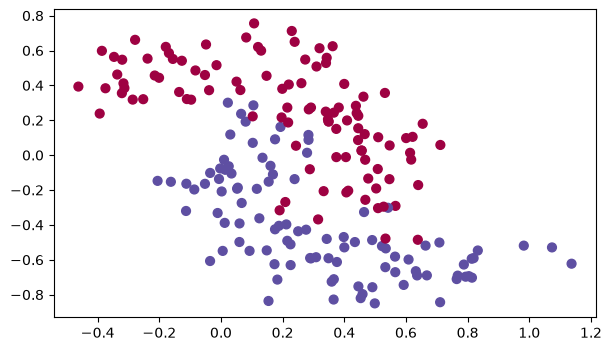

In [2]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

## 4 - Non-Regularized Model

3-layer network: LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID.
Can run in regularization mode (`lambd` != 0) or dropout mode (`keep_prob` < 1).

In [3]:
def model(X, Y, learning_rate=0.3, num_iterations=30000, print_cost=True, lambd=0, keep_prob=1):
    """
    Implements a three-layer neural network: LINEAR->RELU->LINEAR->RELU->LINEAR->SIGMOID.

    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (output size, number of examples)
    learning_rate -- learning rate of the optimization
    num_iterations -- number of iterations of the optimization loop
    print_cost -- If True, print the cost every 10000 iterations
    lambd -- regularization hyperparameter, scalar
    keep_prob - probability of keeping a neuron active during drop-out, scalar.

    Returns:
    parameters -- parameters learned by the model. They can then be used to predict.
    """

    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 20, 3, 1]

    parameters = initialize_parameters(layers_dims)

    for i in range(0, num_iterations):

        if keep_prob == 1:
            a3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            a3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)

        if lambd == 0:
            cost = compute_cost(a3, Y)
        else:
            cost = compute_cost_with_regularization(a3, Y, parameters, lambd)

        assert (lambd == 0 or keep_prob == 1)
        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X, Y, cache)
        elif lambd != 0:
            grads = backward_propagation_with_regularization(X, Y, cache, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)

        parameters = update_parameters(parameters, grads, learning_rate)

        if print_cost and i % 10000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
        if print_cost and i % 1000 == 0:
            costs.append(cost)

    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

Cost after iteration 0: 1.097278475219203


/Users/altugikiz/Documents/GitHub/DL-from-scratch/12-regularization/reg_utils.py:155: RuntimeWarning: divide by zero encountered in log
  logprobs = np.multiply(-np.log(a3), Y) + np.multiply(-np.log(1 - a3), 1 - Y)
/Users/altugikiz/Documents/GitHub/DL-from-scratch/12-regularization/reg_utils.py:155: RuntimeWarning: invalid value encountered in multiply
  logprobs = np.multiply(-np.log(a3), Y) + np.multiply(-np.log(1 - a3), 1 - Y)


Cost after iteration 10000: 0.08798500568849722
Cost after iteration 20000: 0.07317783476822838


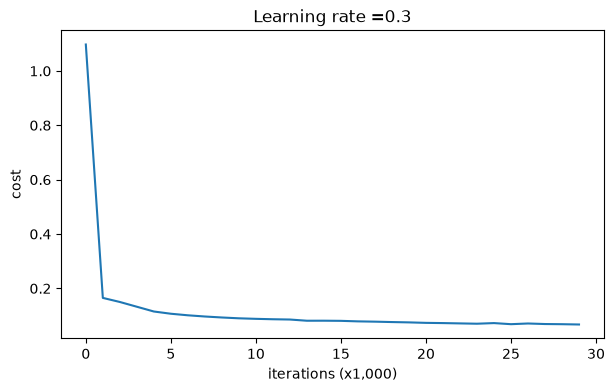

On the training set:
Accuracy: 0.975
On the test set:
Accuracy: 1.0


In [4]:
parameters = model(train_X, train_Y)
print("On the training set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

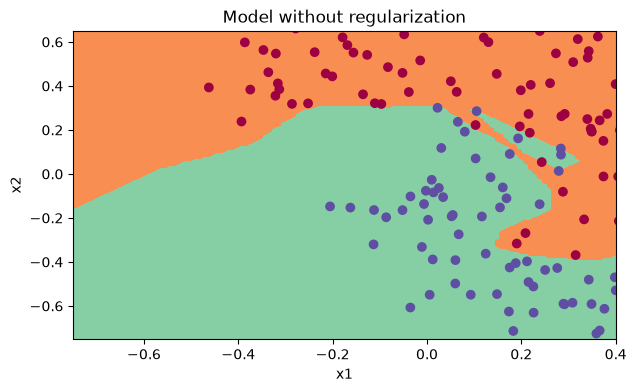

In [5]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

The non-regularized model is fitting the noisy points -- it's overfitting the training set.
Let's look at two techniques to reduce that.

## 5 - L2 Regularization

### Exercise 1 - compute_cost_with_regularization

In [6]:
# GRADED FUNCTION: compute_cost_with_regularization

def compute_cost_with_regularization(A3, Y, parameters, lambd):
    """
    Implement the cost function with L2 regularization.

    Arguments:
    A3 -- post-activation, output of forward propagation, of shape (output size, number of examples)
    Y -- "true" labels vector, of shape (output size, number of examples)
    parameters -- python dictionary containing parameters of the model

    Returns:
    cost - value of the regularized loss function
    """
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]

    cross_entropy_cost = compute_cost(A3, Y)

    L2_regularization_cost = (1. / m) * (lambd / 2) * (
        np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3))
    )

    cost = cross_entropy_cost + L2_regularization_cost

    return cost

In [7]:
A3, t_Y, parameters = compute_cost_with_regularization_test_case()
cost = compute_cost_with_regularization(A3, t_Y, parameters, lambd=0.1)
print("cost = " + str(cost))

compute_cost_with_regularization_test(compute_cost_with_regularization)

cost = 1.7864859451590758
All tests passed.


### Exercise 2 - backward_propagation_with_regularization

In [8]:
# GRADED FUNCTION: backward_propagation_with_regularization

def backward_propagation_with_regularization(X, Y, cache, lambd):
    """
    Implements the backward propagation of our baseline model to which we added an L2 regularization.

    Arguments:
    X -- input dataset, of shape (input size, number of examples)
    Y -- "true" labels vector, of shape (output size, number of examples)
    cache -- cache output from forward_propagation()
    lambd -- regularization hyperparameter, scalar

    Returns:
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables
    """

    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1. / m * np.dot(dZ3, A2.T) + (lambd / m) * W3
    db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1. / m * np.dot(dZ2, A1.T) + (lambd / m) * W2
    db2 = 1. / m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1. / m * np.dot(dZ1, X.T) + (lambd / m) * W1
    db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

In [9]:
t_X, t_Y, cache = backward_propagation_with_regularization_test_case()

grads = backward_propagation_with_regularization(t_X, t_Y, cache, lambd=0.7)
print("dW1 = \n" + str(grads["dW1"]))
print("dW2 = \n" + str(grads["dW2"]))
print("dW3 = \n" + str(grads["dW3"]))
backward_propagation_with_regularization_test(backward_propagation_with_regularization)

dW1 = 
[[-0.25604646  0.12298827 -0.28297129]
 [-0.17706303  0.34536094 -0.4410571 ]]
dW2 = 
[[ 0.79276486  0.85133918]
 [-0.0957219  -0.01720463]
 [-0.13100772 -0.03750433]]
dW3 = 
[[-1.77691347 -0.11832879 -0.09397446]]
All tests passed.


Cost after iteration 0: 1.1852806608154085
Cost after iteration 10000: 0.22395354762233213
Cost after iteration 20000: 0.22122205353722751


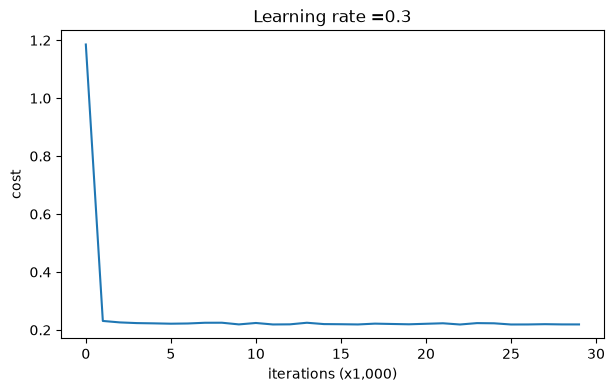

On the train set:
Accuracy: 0.93
On the test set:
Accuracy: 1.0


In [10]:
parameters = model(train_X, train_Y, lambd=0.7)
print("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

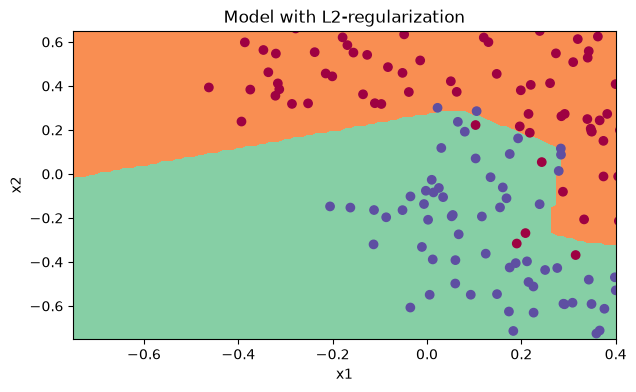

In [11]:
plt.title("Model with L2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**What you should remember about L2-regularization:**
- A regularization term is added to the cost.
- There are extra terms in the gradients with respect to weight matrices.
- Weights end up smaller ("weight decay") -- pushed to smaller values.

## 6 - Dropout

Dropout randomly shuts down some neurons in each iteration. At each iteration, you train
a different "thinned" version of the network -- neurons become less reliant on any one
other specific neuron, since that neuron might be dropped at any time.

### 6.1 - Forward Propagation with Dropout

### Exercise 3 - forward_propagation_with_dropout

In [12]:
# GRADED FUNCTION: forward_propagation_with_dropout

def forward_propagation_with_dropout(X, parameters, keep_prob=0.5):
    """
    Implements the forward propagation: LINEAR -> RELU + DROPOUT -> LINEAR -> RELU + DROPOUT -> LINEAR -> SIGMOID.

    Arguments:
    X -- input dataset, of shape (2, number of examples)
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3"
    keep_prob - probability of keeping a neuron active during drop-out, scalar

    Returns:
    A3 -- last activation value, output of the forward propagation
    cache -- tuple, information stored for computing the backward propagation
    """

    np.random.seed(1)

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    D1 = np.random.rand(A1.shape[0], A1.shape[1])
    D1 = (D1 < keep_prob).astype(int)
    A1 = A1 * D1
    A1 = A1 / keep_prob

    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    D2 = np.random.rand(A2.shape[0], A2.shape[1])
    D2 = (D2 < keep_prob).astype(int)
    A2 = A2 * D2
    A2 = A2 / keep_prob

    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)

    return A3, cache

In [13]:
t_X, parameters = forward_propagation_with_dropout_test_case()

A3, cache = forward_propagation_with_dropout(t_X, parameters, keep_prob=0.7)
print("A3 = " + str(A3))

forward_propagation_with_dropout_test(forward_propagation_with_dropout)

A3 = [[0.99999749 0.99990322 0.99999727]]
All tests passed.


### 6.2 - Backward Propagation with Dropout

### Exercise 4 - backward_propagation_with_dropout

In [14]:
# GRADED FUNCTION: backward_propagation_with_dropout

def backward_propagation_with_dropout(X, Y, cache, keep_prob):
    """
    Implements the backward propagation of our baseline model to which we added dropout.

    Arguments:
    X -- input dataset, of shape (2, number of examples)
    Y -- "true" labels vector, of shape (output size, number of examples)
    cache -- cache output from forward_propagation_with_dropout()
    keep_prob - probability of keeping a neuron active during drop-out, scalar

    Returns:
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables
    """

    m = X.shape[1]
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1. / m * np.dot(dZ3, A2.T)
    db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)
    dA2 = np.dot(W3.T, dZ3)

    dA2 = dA2 * D2
    dA2 = dA2 / keep_prob

    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1. / m * np.dot(dZ2, A1.T)
    db2 = 1. / m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)

    dA1 = dA1 * D1
    dA1 = dA1 / keep_prob

    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1. / m * np.dot(dZ1, X.T)
    db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

In [15]:
t_X, t_Y, cache = backward_propagation_with_dropout_test_case()

gradients = backward_propagation_with_dropout(t_X, t_Y, cache, keep_prob=0.8)

print("dA1 = \n" + str(gradients["dA1"]))
print("dA2 = \n" + str(gradients["dA2"]))

backward_propagation_with_dropout_test(backward_propagation_with_dropout)

dA1 = 
[[-9.55418087e-05  8.51635449e-01 -8.59677371e-03]
 [ 9.26869231e-05 -1.86633447e+00  8.33989343e-03]]
dA2 = 
[[-8.55953049e-05  1.19413423e+00 -7.70179544e-03]
 [-6.74153352e-05  9.40506719e-01 -6.06597665e-03]
 [-3.75733950e-05  0.00000000e+00 -3.38082331e-03]]
All tests passed.


Cost after iteration 0: 1.1429329045746122
Cost after iteration 10000: 0.08177609289931886
Cost after iteration 20000: 0.0728412265213345


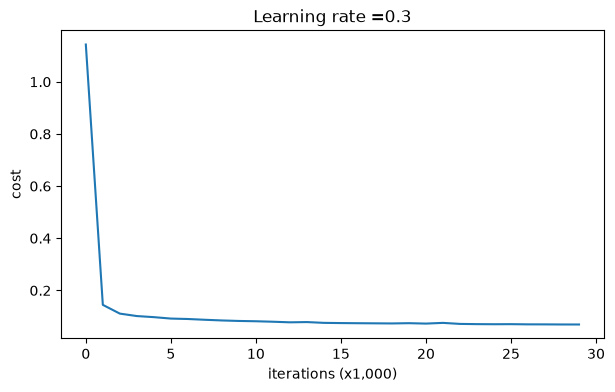

On the train set:
Accuracy: 0.94
On the test set:
Accuracy: 1.0


In [16]:
parameters = model(train_X, train_Y, keep_prob=0.86, learning_rate=0.3)

print("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

/Users/altugikiz/Documents/GitHub/DL-from-scratch/12-regularization/reg_utils.py:17: RuntimeWarning: overflow encountered in exp
  s = 1 / (1 + np.exp(-x))


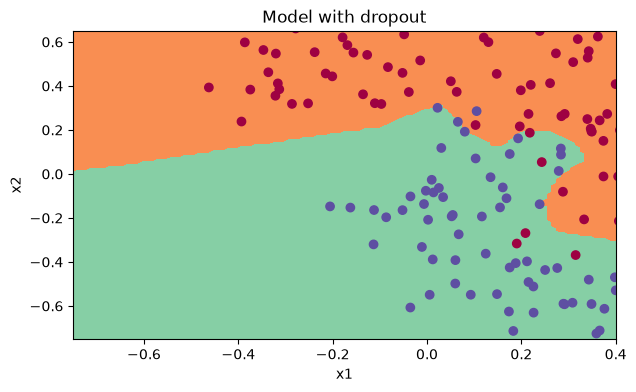

In [17]:
plt.title("Model with dropout")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**Note:**
- A common mistake is using dropout both in training and testing. Use dropout
  (randomly eliminate nodes) only during **training** -- never at test time.

**What you should remember about dropout:**
- Dropout is a regularization technique.
- Only use dropout during training, not during test time.
- Apply dropout both during forward and backward propagation.
- During training, divide each dropout layer by `keep_prob` to keep the same expected
  value for the activations ("inverted dropout").

## 7 - Conclusions

| Model | Train accuracy | Test accuracy |
|---|---|---|
| 3-layer NN without regularization | 95% | 91.5% |
| 3-layer NN with L2-regularization | 94% | 93% |
| 3-layer NN with dropout | 93% | 95% |

*(Reference numbers from the original assignment's dataset -- your synthetic-dataset run
will differ in exact values but should show the same pattern.)*

Regularization hurts training set performance -- it limits the network's ability to
overfit the training set. But since it ultimately gives better test accuracy, it's
helping the system generalize.

**Main takeaways:**
- Regularization will help you reduce overfitting.
- Regularization will drive your weights to lower values.
- L2 regularization and Dropout are two very effective regularization techniques.